In [1]:
from pathlib import Path
import sys


SCENARIO_DIR = Path.cwd()
REPO_ROOT = SCENARIO_DIR.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline


SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}

max_routes = 1
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
)

In [2]:
def print_pair_data(pair):
    print(','.join([f"{node:3d}" for node in result.annotation.annotated_routes_by_pair[pair][0].node_path]))
    print(','.join([f"{net:3d}" for net in result.annotation.annotated_routes_by_pair[pair][0].network_path]))
    print(f"Boundries: {result.annotation.annotated_routes_by_pair[pair][0].boundary_crossings}")
    print(f"HBH: {" ".join([f"{req}" for req in result.security.plans_by_model[SecurityModelType.HOP_BY_HOP][pair][0].key_requirements])}")
    print(f"E2E: {" ".join([f"{req}" for req in result.security.plans_by_model[SecurityModelType.END_TO_END][pair][0].key_requirements])}")
    print(f"EBE: {" ".join([f"{req}" for req in result.security.plans_by_model[SecurityModelType.EDGE_BY_EDGE][pair][0].key_requirements])}")
    print(f"ETE: {" ".join([f"{req}" for req in result.security.plans_by_model[SecurityModelType.EDGE_TO_EDGE][pair][0].key_requirements])}")

In [3]:
print_pair_data((1,12))

  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12
  1,  1,  1,  1,  2,  2,  2,  2,  3,  3,  3,  3
Boundries: (4->5, 8->9)
HBH: NODE_TO_NODE(1->2) NODE_TO_NODE(2->3) NODE_TO_NODE(3->4) NODE_TO_NODE(4->5) NODE_TO_NODE(5->6) NODE_TO_NODE(6->7) NODE_TO_NODE(7->8) NODE_TO_NODE(8->9) NODE_TO_NODE(9->10) NODE_TO_NODE(10->11) NODE_TO_NODE(11->12)
E2E: NODE_TO_NODE(1->12)
EBE: NODE_TO_GROUP(1->1) GROUP_TO_GROUP(1->2) NODE_TO_GROUP(5->2) GROUP_TO_GROUP(2->3) NODE_TO_NODE(9->12)
ETE: NODE_TO_GROUP(1->1) GROUP_TO_GROUP(1->3) NODE_TO_NODE(9->12)


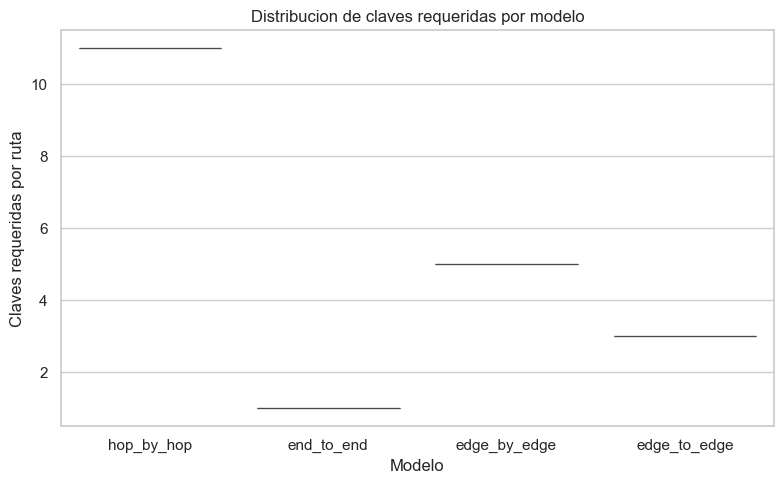

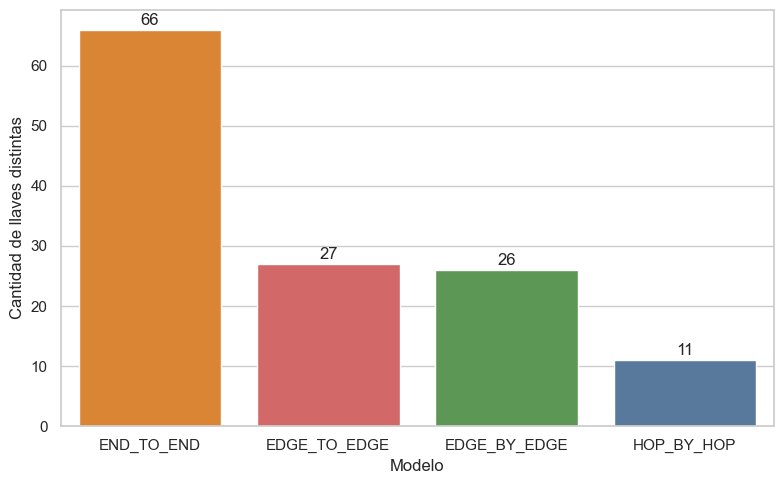

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
    "hbh": "#4c78a8",
    "e2e": "#f58518",
    "ebe": "#54a24b",
    "ete": "#e45756",
    "hop_by_hop": "#4c78a8",
    "end_to_end": "#f58518",
    "edge_by_edge": "#54a24b",
    "edge_to_edge": "#e45756",
}


def palette_for(values):
    unique_values = list(dict.fromkeys(values))
    return {value: MODEL_PALETTE.get(value, "#4c78a8") for value in unique_values}

rows = []

for model, plans_by_pair in result.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        if pair==(1,12):
            for plan in plans:
                unique_scopes = {req.scope for req in plan.key_requirements}
                rows.append(
                    {
                        "model": model.name.lower(),
                        "pair": f"{pair[0]}->{pair[1]}",
                        "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                        "required_keys": len(unique_scopes),
                    }
                )

df_keys = pd.DataFrame(rows)
plt.figure(figsize=(8, 5))
sns.boxenplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    dodge=False,
    palette=palette_for(df_keys["model"]),
    legend=False,
)
plt.title("Distribucion de claves requeridas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Claves requeridas por ruta")
plt.tight_layout()
plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

MODEL_PALETTE = {
    "HOP_BY_HOP": "#4c78a8",
    "END_TO_END": "#f58518",
    "EDGE_BY_EDGE": "#54a24b",
    "EDGE_TO_EDGE": "#e45756",
    "hbh": "#4c78a8",
    "e2e": "#f58518",
    "ebe": "#54a24b",
    "ete": "#e45756",
    "hop_by_hop": "#4c78a8",
    "end_to_end": "#f58518",
    "edge_by_edge": "#54a24b",
    "edge_to_edge": "#e45756",
}


def palette_for(values):
    unique_values = list(dict.fromkeys(values))
    return {value: MODEL_PALETTE.get(value, "#4c78a8") for value in unique_values}

from modules.security.models import SecurityModelType
from pipelines.route_activation import RouteActivationPlanner

planner = RouteActivationPlanner()

rows = []
for label, sim_result in [("Dirigidas", result)]:
    for model in SecurityModelType:
        rows.append(
            {
                "mode": label,
                "model": model.name,
                "unique_keys": len(planner.build_for_model(sim_result.security, model=model).key_scopes),
            }
        )

df = pd.DataFrame(rows)

pivot = df.pivot(index="model", columns="mode", values="unique_keys").reset_index()
pivot = pivot.sort_values("Dirigidas", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=pivot,
    x="model",
    y="Dirigidas",
    hue="model",
    dodge=False,
    palette=palette_for(pivot["model"]),
    legend=False,
)
ax.set_ylabel("Cantidad de llaves distintas")
ax.set_xlabel("Modelo")

for i, value in enumerate(pivot["Dirigidas"]):
    ax.text(i, value + 0.3, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()



## Maximizar rutas sujeto a presupuesto de llaves

:::: {layout="[0.5, 0.5]"}

:::{#firstcol}
\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
B &: \text{presupuesto máximo de llaves activas} \\
\end{aligned}
:::

:::{#secondcol}
\begin{aligned}
\max \quad & \sum_{r \in R} x_r \\
\text{s.a.} \quad
& \sum_{k \in K} y_k \le B \\
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
:::


::::


In [5]:
import pandas as pd

df_m1 = pd.DataFrame()
for sec_model in SERIES_COLORS.keys():
    from models.model1_max_routes import solve_for_security_model
    
    df_m1 = pd.concat([df_m1,solve_for_security_model(result, sec_model)])

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar


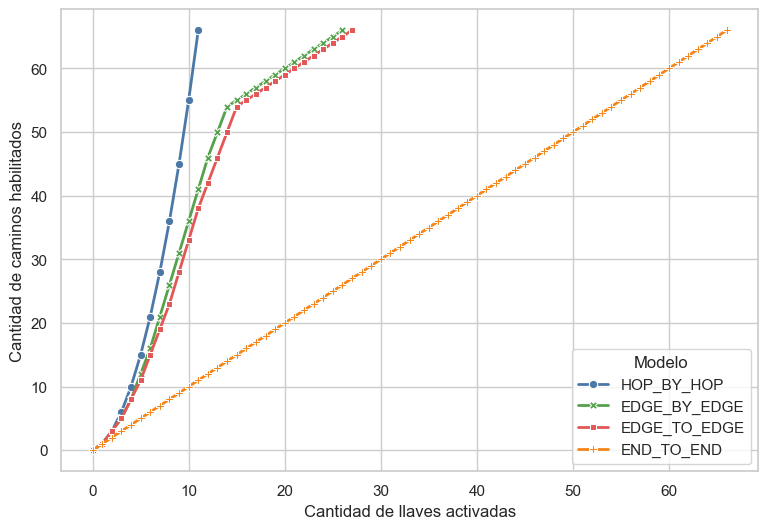

In [6]:
#| echo: false
plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=df_m1.sort_values("selected_keys"),
    x="selected_keys",
    y="selected_routes",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    palette=palette_for(df_m1["model"]),
)
ax.set_xlabel("Cantidad de llaves activadas")
ax.set_ylabel("Cantidad de caminos habilitados")
ax.legend(title="Modelo")
plt.show()


## Minimizar llaves para un porcentaje de conectividad entre pares


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\alpha &: \text{fracción o porcentaje objetivo de conectividad}
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
$$
z_p =
\begin{cases}
1 & \text{si el par } p \text{ tiene al menos 1 ruta } \\
0 & \text{en otro caso}
\end{cases}
$$

:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \le z_p \qquad \forall p \in P,\ \forall r \in R_p \\
& z_p \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& \sum_{p \in P} z_p \ge \left\lceil \alpha |P| \right\rceil \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
& z_p \in \{0,1\} \qquad \forall p \in P
\end{aligned}

:::


::::


In [7]:
import pandas as pd


df_m2 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model2_min_keys import solve_for_security_model
    
    df_m2 = pd.concat([df_m2, solve_for_security_model(result,sec_model)], ignore_index=True)

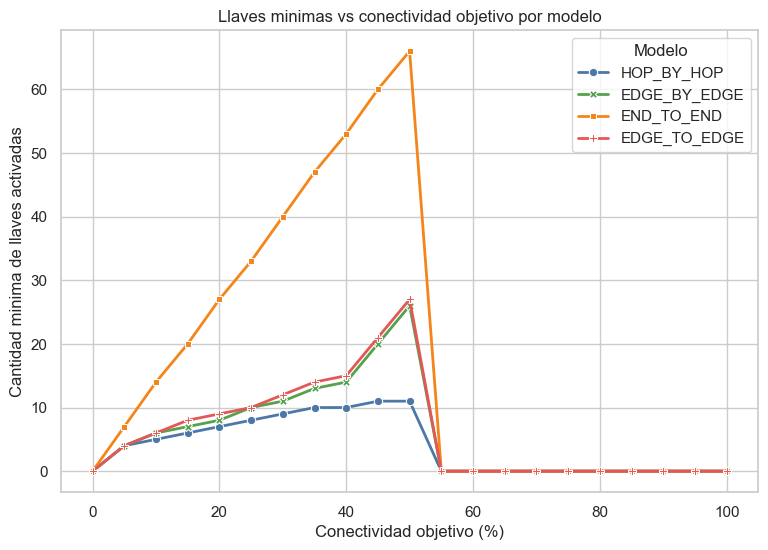

In [8]:
#| echo: false
plt.figure(figsize=(9, 6))
ax = sns.lineplot(
    data=df_m2.sort_values("target_connectivity_pct"),
    x="target_connectivity_pct",
    y="selected_keys",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    palette=palette_for(df_m2["model"]),
)
ax.set_xlabel("Conectividad objetivo (%)")
ax.set_ylabel("Cantidad minima de llaves activadas")
ax.set_title("Llaves minimas vs conectividad objetivo por modelo")
ax.legend(title="Modelo")
plt.show()


## Minimizar llaves garantizando al menos 1 camino por par


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& 1 \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
\end{aligned}

:::


::::


In [9]:
import pandas as pd


df_m3 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model3_min_keys_full_connectivity import solve_for_security_model
    
    df_m3 = pd.concat([df_m3, solve_for_security_model(result,sec_model)], ignore_index=True)

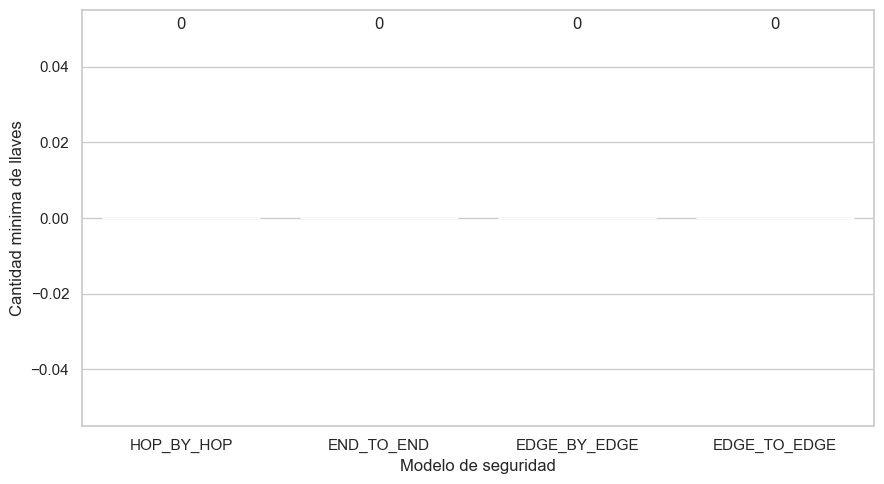

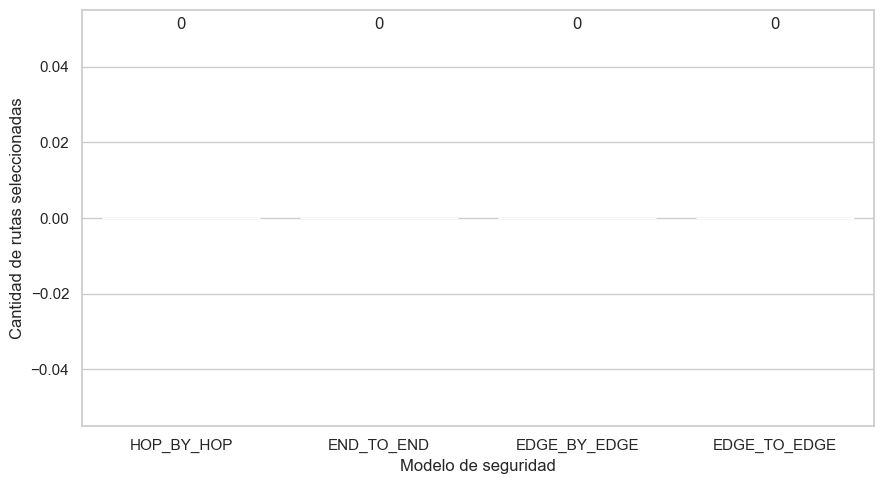

In [10]:
#| label: fig-gapminder
#| fig-cap: "Resultados de modelo 3"
#| fig-subcap:
#|   - "Llaves minimas para garantizar al menos 1 camino por par"
#|   - "Rutas seleccionadas en la solucion optima"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

plot_df = df_m3.sort_values("selected_keys").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_keys",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad minima de llaves")

for i, value in enumerate(plot_df["selected_keys"]):
    ax.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

plot_df = df_m3.sort_values("selected_routes").copy()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=plot_df,
    x="model",
    y="selected_routes",
    hue="model",
    dodge=False,
    palette=palette_for(plot_df["model"]),
    legend=False,
)
ax.set_xlabel("Modelo de seguridad")
ax.set_ylabel("Cantidad de rutas seleccionadas")

for i, value in enumerate(plot_df["selected_routes"]):
    ax.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()
